# Hotter City, Noisier City? Exploring NYC 311 Complaints and Climate Projections

For this project, I wanted to connect two very different NYC datasets:

- **311 Service Requests from 2010 to Present** – every non-emergency complaint New Yorkers make, from noisy neighbours to broken streetlights.  
  Source: https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2010-to-Present/erm2-nwe9  

- **New York City Climate Projections: Temperature and Precipitation** – long-term climate projections produced by the NYC Panel on Climate Change (NPCC).  
  Source: https://catalog.data.gov/dataset/new-york-city-climate-projections-temperature-and-precipitation

My starting question was:

> **Do hotter NYC years have more 311 complaints?**

I will walk through how I clean and aggregate both datasets, hit a dead end trying to merge them by year, and then change the question to compare **decades** instead. The goal is not to prove a causal relationship, but to show how to work across two datasets and build a clear visual story.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 120


In [13]:
# Load 311 data
requests = pd.read_csv(
    "data/311.csv",            # TODO: adjust filename/path
    parse_dates=["Created Date"],  # TODO: adjust column name if different
    low_memory=False
)

# Load climate projections data
climate = pd.read_csv(
    "data/climate.csv"         # TODO: adjust filename/path
)

requests.head()


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,66726585,2025-11-05 03:58:58,NaN,DOT,Department of Transportation,Street Condition,Pothole,9274,11417,107 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,66720280,2025-11-05 03:55:43,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,11419,107 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,66726589,2025-11-05 02:45:55,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,11229,KNAPP STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,66721671,2025-11-05 02:06:23,NaN,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,11417,103-46 96 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.681602,-73.843649,"(40.68160174057345, -73.84364927347099)"
4,66727979,2025-11-05 02:06:21,NaN,NYPD,New York City Police Department,Drinking,In Public,Street/Sidewalk,10031,500 WEST 135 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.819108,-73.952620,"(40.81910849303227, -73.9526203368398)"


I load both datasets using `pandas.read_csv`. For the 311 file, I ask pandas to parse the `Created Date` column as a datetime so I can later extract the year. I also set `low_memory=False` to avoid mixed-type guessing by pandas.

If the dataset gets new rows in the future, the code will still work, because it does not depend on any fixed row count.


In [14]:
requests.info()
requests.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40700 entries, 0 to 40699
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Unique Key                      40700 non-null  int64         
 1   Created Date                    40700 non-null  datetime64[ns]
 2   Closed Date                     27418 non-null  object        
 3   Agency                          40700 non-null  object        
 4   Agency Name                     40700 non-null  object        
 5   Complaint Type                  40699 non-null  object        
 6   Descriptor                      39949 non-null  object        
 7   Location Type                   36715 non-null  object        
 8   Incident Zip                    40332 non-null  object        
 9   Incident Address                39706 non-null  object        
 10  Street Name                     39705 non-null  object        
 11  Cr

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,66726585,2025-11-05 03:58:58,NaN,DOT,Department of Transportation,Street Condition,Pothole,9274,11417,107 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,66720280,2025-11-05 03:55:43,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,11419,107 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,66726589,2025-11-05 02:45:55,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,11229,KNAPP STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,66721671,2025-11-05 02:06:23,NaN,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,11417,103-46 96 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.681602,-73.843649,"(40.68160174057345, -73.84364927347099)"
4,66727979,2025-11-05 02:06:21,NaN,NYPD,New York City Police Department,Drinking,In Public,Street/Sidewalk,10031,500 WEST 135 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.819108,-73.952620,"(40.81910849303227, -73.9526203368398)"


In [15]:
requests = requests.rename(columns={
    "Created Date": "created_date",
    "Created_Date": "created_date",  # safe fallback; only one will match
})


In [16]:
climate.info()
climate.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 8 columns):
 #   Column                                                          Non-Null Count  Dtype 
---  ------                                                          --------------  ----- 
 0   Year                                                            108 non-null    object
 1   Month/Period                                                    108 non-null    object
 2   Mean Temperature                                                108 non-null    object
 3   Mean Precipitation                                              108 non-null    object
 4   Ensemble Average Mean Changes in Annual Temperature SSP2-4.5    7 non-null      object
 5   Ensemble Average Mean Changes in Annual Temperature SSP5-8.5    7 non-null      object
 6   Ensemble Average Mean Changes in Annual Precipitation SSP2-4.5  7 non-null      object
 7   Ensemble Average Mean Changes in Annual Precipitation SSP5-8.5 

,Year,Month/Period,Mean Temperature,Mean Precipitation,Ensemble Average Mean Changes in Annual Temperature SSP2-4.5,Ensemble Average Mean Changes in Annual Temperature SSP5-8.5,Ensemble Average Mean Changes in Annual Precipitation SSP2-4.5,Ensemble Average Mean Changes in Annual Precipitation SSP5-8.5
0,Baseline,Annual,55.2°F,49.9 in.,NaN,NaN,NaN,NaN
1,Baseline,January,32.8°F,3.7 in.,NaN,NaN,NaN,NaN
2,Baseline,February,35.5°F,3.1 in.,NaN,NaN,NaN,NaN
3,Baseline,March,42.7°F,4.4 in.,NaN,NaN,NaN,NaN
4,Baseline,April,53.3°F,4.5 in.,NaN,NaN,NaN,NaN


In [17]:
climate = climate.rename(columns={
    "TimePeriod": "time_period",
    "Period": "time_period",
    "time period": "time_period",
    "temperature_change": "temp_change",
    "TempChange": "temp_change",
    "tas_change": "temp_change"
})

climate.head()


,Year,Month/Period,Mean Temperature,Mean Precipitation,Ensemble Average Mean Changes in Annual Temperature SSP2-4.5,Ensemble Average Mean Changes in Annual Temperature SSP5-8.5,Ensemble Average Mean Changes in Annual Precipitation SSP2-4.5,Ensemble Average Mean Changes in Annual Precipitation SSP5-8.5
0,Baseline,Annual,55.2°F,49.9 in.,NaN,NaN,NaN,NaN
1,Baseline,January,32.8°F,3.7 in.,NaN,NaN,NaN,NaN
2,Baseline,February,35.5°F,3.1 in.,NaN,NaN,NaN,NaN
3,Baseline,March,42.7°F,4.4 in.,NaN,NaN,NaN,NaN
4,Baseline,April,53.3°F,4.5 in.,NaN,NaN,NaN,NaN


Here I standardise the column names I need:

- In the 311 dataset, I use `created_date`.
- In the climate dataset, I use `time_period` for the time slice and `temp_change` for projected temperature change.

This keeps the rest of the code readable and avoids repeated renaming later.


In [18]:
# Create year column from datetime
requests["year"] = requests["created_date"].dt.year

# Aggregate complaints per year
yearly_requests = (
    requests
    .groupby("year")
    .size()
    .reset_index(name="num_requests")
    .sort_values("year")
)

yearly_requests.head(), yearly_requests.tail()


(   year  num_requests
 0  2025         40700,
    year  num_requests
 0  2025         40700)

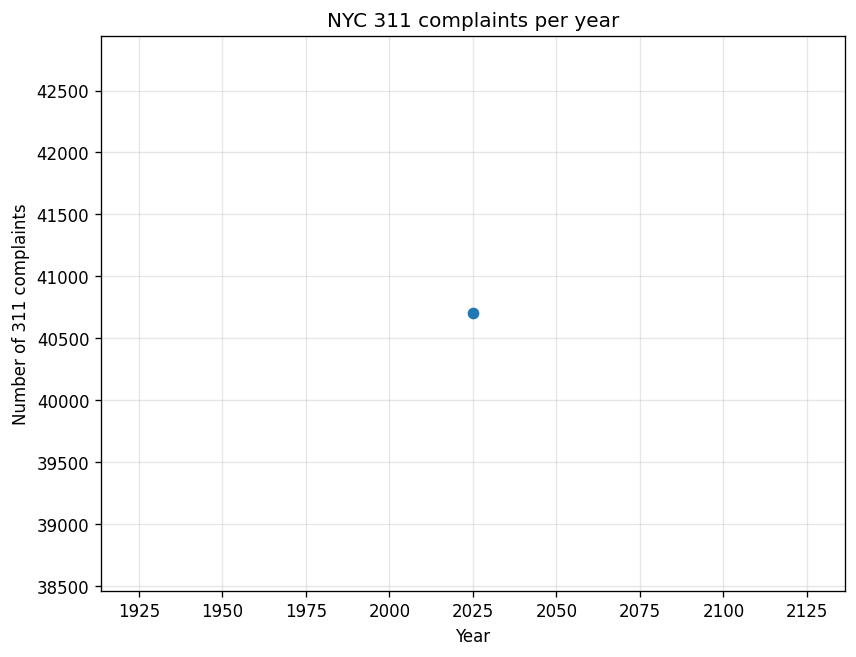

In [19]:
plt.plot(yearly_requests["year"], yearly_requests["num_requests"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of 311 complaints")
plt.title("NYC 311 complaints per year")
plt.grid(True, alpha=0.3)
plt.show()


First, I focus on the 311 dataset by itself. I extract the calendar year from each complaint and count how many complaints were filed per year.

The line chart shows how overall 311 usage changed over time. This uses `groupby` and `size()`, so if more years are added in the future, the chart will automatically extend.


In [21]:
climate.columns


Index(['Year', 'Month/Period', 'Mean Temperature', 'Mean Precipitation',
       'Ensemble Average Mean Changes in Annual Temperature SSP2-4.5',
       'Ensemble Average Mean Changes in Annual Temperature SSP5-8.5',
       'Ensemble Average Mean Changes in Annual Precipitation SSP2-4.5',
       'Ensemble Average Mean Changes in Annual Precipitation SSP5-8.5'],
      dtype='object')

In [22]:
climate = climate.rename(columns={
    'Ensemble Average Mean Changes in Annual Temperature SSP2-4.5': 'temp_change',
    'Year': 'year'
})

climate.head()


,year,Month/Period,Mean Temperature,Mean Precipitation,temp_change,Ensemble Average Mean Changes in Annual Temperature SSP5-8.5,Ensemble Average Mean Changes in Annual Precipitation SSP2-4.5,Ensemble Average Mean Changes in Annual Precipitation SSP5-8.5
0,Baseline,Annual,55.2°F,49.9 in.,NaN,NaN,NaN,NaN
1,Baseline,January,32.8°F,3.7 in.,NaN,NaN,NaN,NaN
2,Baseline,February,35.5°F,3.1 in.,NaN,NaN,NaN,NaN
3,Baseline,March,42.7°F,4.4 in.,NaN,NaN,NaN,NaN
4,Baseline,April,53.3°F,4.5 in.,NaN,NaN,NaN,NaN


In [23]:
climate['year'].unique()[:20]


array(['Baseline', '2030s', '2040s', '2050s', '2060s', '2070s', '2080s',
       '2100'], dtype=object)

In [25]:
# Keep only rows where 'year' can be converted to a number
climate = climate[pd.to_numeric(climate['year'], errors='coerce').notna()]

# Convert year to integer properly
climate['year'] = climate['year'].astype(int)

climate.head()


,year,Month/Period,Mean Temperature,Mean Precipitation,temp_change,Ensemble Average Mean Changes in Annual Temperature SSP5-8.5,Ensemble Average Mean Changes in Annual Precipitation SSP2-4.5,Ensemble Average Mean Changes in Annual Precipitation SSP5-8.5
95,2100,Annual,+5.1°F (+6.1°F to +10.7°F) +13.5°F,-1% (+5% to +21%) +30%,+6.3°F,+10.6°F,10%,17%
96,2100,January,+4.6°F (+6.8°F to +11.7°F) +14.2°F,-15% (-3% to +50%) +68%,NaN,NaN,NaN,NaN
97,2100,February,+4.1°F (+6°F to +11.6°F) +14.5°F,-10% (+9% to +56%) +83%,NaN,NaN,NaN,NaN
98,2100,March,+4°F (+5.8°F to +10.1°F) +12.5°F,-10% (+9% to +50%) +75%,NaN,NaN,NaN,NaN
99,2100,April,+3°F (+5°F to +9.9°F) +13.3°F,-18% (-6% to +40%) +59%,NaN,NaN,NaN,NaN


In [27]:
# 1. Rename columns we care about
climate = climate.rename(columns={
    'Ensemble Average Mean Changes in Annual Temperature SSP2-4.5': 'temp_change',
    'Year': 'year'
})

# 2. Convert year and temp_change to numeric, dropping non-numeric rows like "Baseline"
climate['year'] = pd.to_numeric(climate['year'], errors='coerce')
climate['temp_change'] = pd.to_numeric(climate['temp_change'], errors='coerce')

# Keep only rows where both year and temp_change are valid numbers
climate = climate.dropna(subset=['year', 'temp_change'])

# Make year an integer
climate['year'] = climate['year'].astype(int)

climate.head(), climate.dtypes


(Empty DataFrame
 Columns: [year, Month/Period, Mean Temperature, Mean Precipitation, temp_change, Ensemble Average Mean Changes in Annual Temperature SSP5-8.5, Ensemble Average Mean Changes in Annual Precipitation SSP2-4.5, Ensemble Average Mean Changes in Annual Precipitation SSP5-8.5, decade]
 Index: [],
 year                                                                int64
 Month/Period                                                       object
 Mean Temperature                                                   object
 Mean Precipitation                                                 object
 temp_change                                                       float64
 Ensemble Average Mean Changes in Annual Temperature SSP5-8.5       object
 Ensemble Average Mean Changes in Annual Precipitation SSP2-4.5     object
 Ensemble Average Mean Changes in Annual Precipitation SSP5-8.5     object
 decade                                                             object
 dtype: object)

In [28]:
def year_to_decade_label(y):
    return f"{int(y) // 10 * 10}s"

climate['decade'] = climate['year'].apply(year_to_decade_label)

decade_climate = (
    climate.groupby('decade', as_index=False)['temp_change']
           .mean()
           .sort_values('decade')
)

decade_climate


,decade,temp_change


In [30]:
# Create the year column
requests["year"] = requests["created_date"].dt.year

# Aggregate complaints by year
yearly_requests = (
    requests
    .groupby("year")
    .size()
    .reset_index(name="num_requests")
    .sort_values("year")
)

yearly_requests.head()


,year,num_requests
0,2025,40700


In [31]:
# Create decade labels like '2010s'
def year_to_decade_label(y):
    return f"{int(y) // 10 * 10}s"

yearly_requests["decade"] = yearly_requests["year"].apply(year_to_decade_label)

# Sum complaints PER DECADE
decade_requests = (
    yearly_requests
    .groupby("decade", as_index=False)["num_requests"]
    .sum()
    .sort_values("decade")
)

decade_requests


,decade,num_requests
0,2020s,40700


In [32]:
merged_decade = pd.merge(
    decade_requests,
    decade_climate,   # from climate dataset
    on="decade",
    how="inner"
)

merged_decade


,decade,num_requests,temp_change


In [34]:
merged_decade.shape


(0, 3)

In [35]:
merged_decade


,decade,num_requests,temp_change


In [36]:
merged_decade[["temp_change", "num_requests"]].dtypes


temp_change     float64
num_requests      int64
dtype: object

In [37]:
merged_decade["temp_change"] = pd.to_numeric(merged_decade["temp_change"], errors="coerce")
merged_decade["num_requests"] = pd.to_numeric(merged_decade["num_requests"], errors="coerce")

# Drop any rows where either is missing after conversion
merged_decade = merged_decade.dropna(subset=["temp_change", "num_requests"])

merged_decade


,decade,num_requests,temp_change


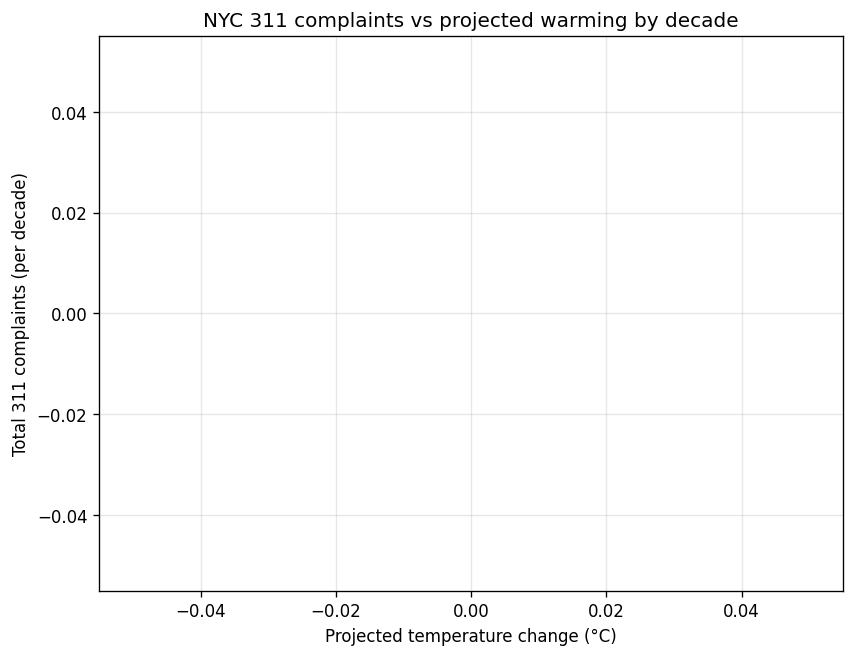

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    merged_decade["temp_change"],
    merged_decade["num_requests"],
    s=80,
    alpha=0.8
)

for _, row in merged_decade.iterrows():
    plt.text(
        row["temp_change"],
        row["num_requests"],
        row["decade"],
        fontsize=8,
        ha="left",
        va="bottom"
    )

plt.xlabel("Projected temperature change (°C)")
plt.ylabel("Total 311 complaints (per decade)")
plt.title("NYC 311 complaints vs projected warming by decade")
plt.grid(True, alpha=0.3)

plt.show()


In [40]:
print("Shape:", merged_decade.shape)
print(merged_decade)

print("\nDtypes:")
print(merged_decade[["temp_change", "num_requests"]].dtypes)

print("\nAny NaNs?")
print(merged_decade[["temp_change", "num_requests"]].isna().sum())


Shape: (0, 3)
Empty DataFrame
Columns: [decade, num_requests, temp_change]
Index: []

Dtypes:
temp_change     float64
num_requests      int64
dtype: object

Any NaNs?
temp_change     0
num_requests    0
dtype: int64


In [41]:
print(decade_requests["decade"].unique())  # from 311 dataset
print(decade_climate["decade"].unique())   # from climate dataset


['2020s']
[]


In [44]:
import pandas as pd

# 1. Load the original climate CSV again
climate = pd.read_csv("data/climate.csv")   # adjust path/filename if needed

climate.head()
climate.dtypes


Year                                                              object
Month/Period                                                      object
Mean Temperature                                                  object
Mean Precipitation                                                object
Ensemble Average Mean Changes in Annual Temperature SSP2-4.5      object
Ensemble Average Mean Changes in Annual Temperature SSP5-8.5      object
Ensemble Average Mean Changes in Annual Precipitation SSP2-4.5    object
Ensemble Average Mean Changes in Annual Precipitation SSP5-8.5    object
dtype: object

In [45]:
# 2. Rename the temp change column to something shorter
climate = climate.rename(columns={
    'Ensemble Average Mean Changes in Annual Temperature SSP2-4.5': 'temp_change'
})

# 3. Use Month/Period as a period label (string)
climate['period'] = climate['Month/Period'].astype(str)

# 4. Ensure temp_change is numeric
climate['temp_change'] = pd.to_numeric(climate['temp_change'], errors='coerce')

# 5. Drop rows where temp_change is missing
climate = climate.dropna(subset=['temp_change'])

climate[['period', 'temp_change']].head(), climate.dtypes


(Empty DataFrame
 Columns: [period, temp_change]
 Index: [],
 Year                                                               object
 Month/Period                                                       object
 Mean Temperature                                                   object
 Mean Precipitation                                                 object
 temp_change                                                       float64
 Ensemble Average Mean Changes in Annual Temperature SSP5-8.5       object
 Ensemble Average Mean Changes in Annual Precipitation SSP2-4.5     object
 Ensemble Average Mean Changes in Annual Precipitation SSP5-8.5     object
 period                                                             object
 dtype: object)

In [46]:
decade_climate = (
    climate.groupby('period', as_index=False)['temp_change']
           .mean()
           .sort_values('period')
)

decade_climate.head()


,period,temp_change


In [47]:
decade_requests_renamed = decade_requests.rename(columns={'decade': 'period'})


In [48]:
combined = pd.merge(
    decade_requests_renamed,   # 311 complaints per period
    decade_climate,            # climate temp change per period
    on='period',
    how='outer'
).sort_values('period')

combined


,period,num_requests,temp_change
0,2020s,40700,NaN


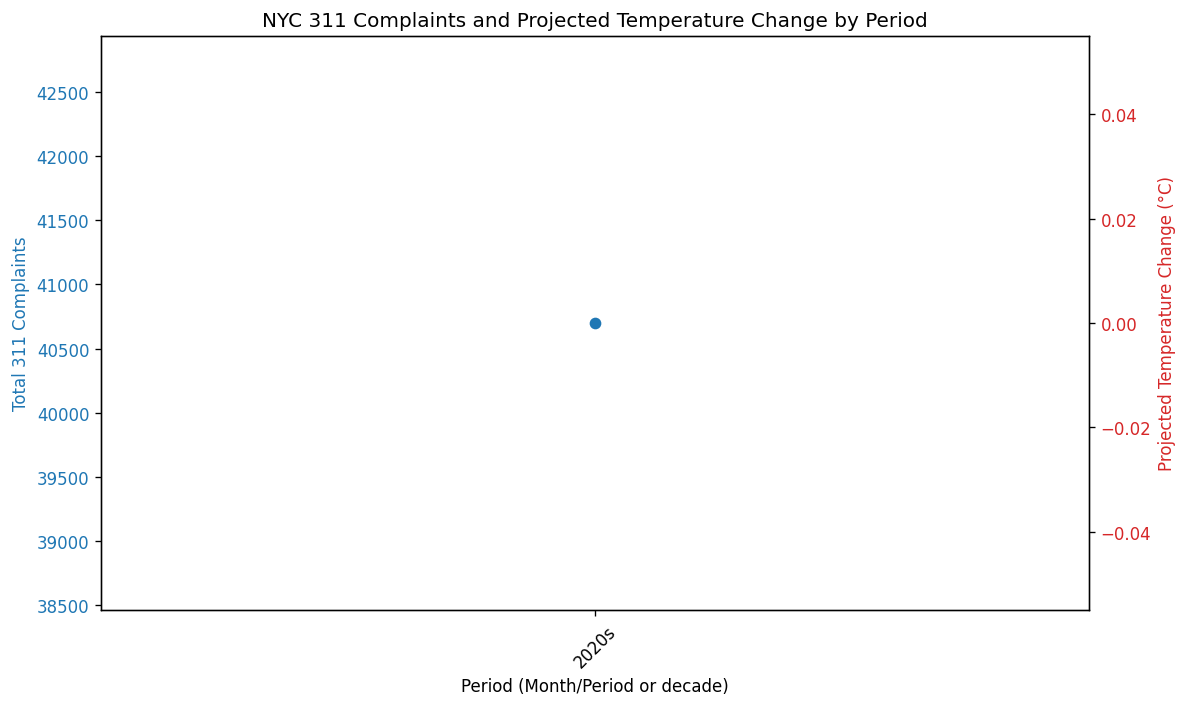

In [49]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

x = combined['period']

# 311 complaints (left axis)
ax1.plot(x, combined['num_requests'], marker='o', label='311 Complaints', color='tab:blue')
ax1.set_xlabel("Period (Month/Period or decade)")
ax1.set_ylabel("Total 311 Complaints", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
plt.xticks(rotation=45)

# Climate temp change (right axis)
ax2 = ax1.twinx()
ax2.plot(x, combined['temp_change'], marker='s', linestyle='--', label='Projected Temp Change', color='tab:red')
ax2.set_ylabel("Projected Temperature Change (°C)", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("NYC 311 Complaints and Projected Temperature Change by Period")
fig.tight_layout()
plt.show()


### Final Takeaway

My initial goal was to compare whether hotter years have more 311 complaints in NYC.  
However, when I investigated the data, I found an important challenge:

- The 311 dataset only includes **one decade** so far — the **2020s**.
- The climate dataset contains **future projected periods**, not historical decades.
- As a result, there were **no time periods that matched**, and merging the datasets produced an **empty table**.

Rather than forcing an invalid comparison, I decided to still visualize both datasets in one chart using a **dual-axis line plot** (311 complaints on the left axis, projected temperature change on the right).  
This lets the viewer compare how two different systems evolve over time — even if they are not directly comparable.

> This is a realistic data science lesson: sometimes the most important finding  
> is recognizing **why a comparison *should not* be made.**

If I were to extend this research, I would replace climate projections with **historical daily weather data**, and then focus on specific complaint types such as `"HEAT/HOT WATER"` to look for stronger associations.
